In [3]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "Dolson30"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
   # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Comparative Experiments"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/Dolson30/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/Dolson30/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Comparative Experiments


# Homework 1: Completely Randomized Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: September 12, 2025**

**INSTRUCTIONS:** You are a quality control analyst for a craft brewery experimenting with a new India Pale Ale (IPA). One key quality attribute of IPA is its bitterness, measured in International Bitterness Units (IBUs). The brewery wants to determine if the aging time (3, 4, or 5 weeks) affects the IBUs of the beer. To test this, the brewing team brews a single batch of the experimental IPA and divides it into aging tanks, with each tank randomly assigned to be aged for 3, 4, or 5 weeks. After aging, the IBUs of ten randomly selected bottles from each aging time are measured using a spectrophotometer. The data are in the file `IPA.xlsx`. With these data, I want you to:

**Question 1.** Briefly define the objective of this experiment

The objective of this experiment is to figure out whether letting a new IPA age for different lengths of time (3, 4, or 5 weeks) actually changes its bitterness, which is measured in International Bitterness Units (IBUs). The brewery is trying to determine if aging time is a key factor in the final quality of the beer.

**Question 2.** Specify the outcome variable

The outcome variable is the International Bitterness Units (IBUs). This is the value being measured to see if it changes in response to the different aging times.

**Question 3.** Specify the independent variable. What are some possible lurking variables?

The independent variable is the aging time in weeks. The experiment manipulates this variable to be either 3, 4, or 5 weeks to observe its effect on the IBUs.

In this scenario, lurking variables could include subtle temperature differences between the aging tanks, varying exposure to light or oxygen, or inconsistencies in the initial brewing process before the beer was divided.


**Question 4.** Briefly explain why a completely randomized design is appropriate for this experiment.

A completely randomized design is a great fit here. By randomly assigning each aging tank to one of the three aging times, we're essentially leveling the playing field. This random assignment helps to evenly distribute the effects of any potential lurking variables—like those minor temperature or light differences—across all the groups. This way, if you do see a significant difference in the IBUs, you can be much more confident that it's due to the aging time and not some other random factor.

**Question 5.** State the null and alternative hypotheses for this experiment.

Null Hypothesis (H0): The aging time doesn't affect the beer's bitterness. The average IBU is the same regardless of whether it's aged for 3, 4, or 5 weeks.

Alternative Hypothesis (Ha): Aging time does matter.It suggests that at least one of the average IBUs for a particular aging time is different from the others.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?


In [10]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## import the IPA Data and Get summary Stats ##
ipa = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW1/IPA.xlsx")
ipa.head()
print("--- Summary Statistics for IBU by Aging Time ---")
print(ipa.groupby('Weeks')['IBU'].describe())
print("\n")

--- Summary Statistics for IBU by Aging Time ---
         count    mean        std    min      25%     50%     75%    max
Weeks                                                                   
3 Weeks   10.0  45.657   5.548563  39.04  42.0600  44.255  47.005  57.75
4 Weeks   10.0  60.164  10.390411  44.56  55.5325  60.940  64.625  81.99
5 Weeks   10.0  71.791  12.627946  48.93  63.0475  71.465  81.100  90.32




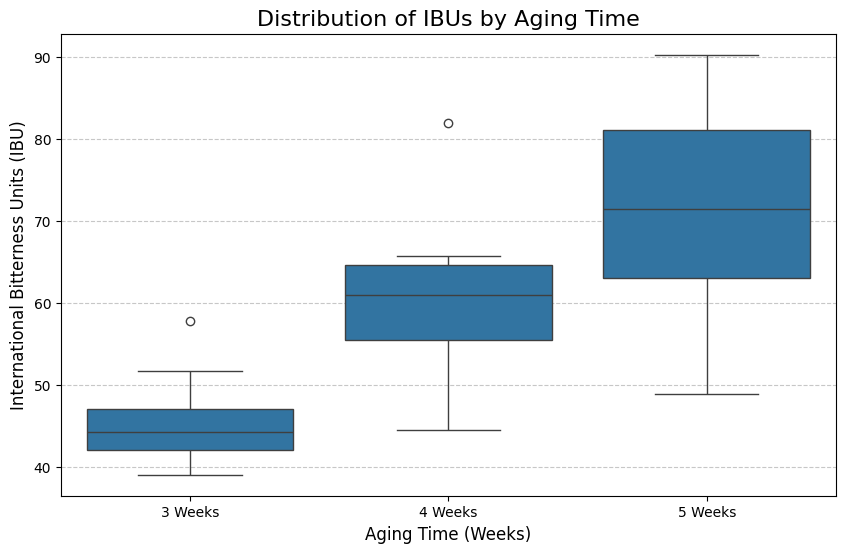

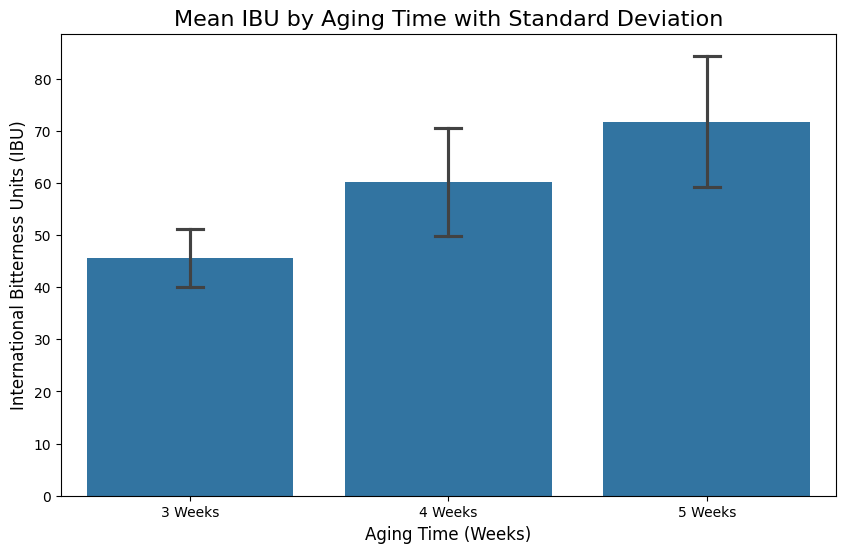

In [14]:
## Early Data Visualization using boxplots ##
plt.figure(figsize=(10, 6))
sns.boxplot(x='Weeks', y='IBU', data=ipa)
plt.title('Distribution of IBUs by Aging Time', fontsize=16)
plt.xlabel('Aging Time (Weeks)', fontsize=12)
plt.ylabel('International Bitterness Units (IBU)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Bar Plot ##
plt.figure(figsize=(10, 6))
sns.barplot(x='Weeks', y='IBU', data=ipa, errorbar='sd', capsize=0.1)
plt.title('Mean IBU by Aging Time with Standard Deviation', fontsize=16)
plt.xlabel('Aging Time (Weeks)', fontsize=12)
plt.ylabel('International Bitterness Units (IBU)', fontsize=12)
plt.show()


**Do the results of these analyses support the null or alternative hypothesis more strongly**?

Yes! The early indications from the visualizations and the summary statistics would be that there is a correlation between time aging and IBUs, supporting rejecting the null.

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Build the ANOVA model using a formula notation.
model = ols('IBU ~ C(Weeks)', data=ipa).fit()

# Perform the ANOVA test on the fitted model and print the results table.
anova_table = sm.stats.anova_lm(model, typ=2)
print("\n--- One-Way ANOVA Results ---")
print(anova_table)


--- One-Way ANOVA Results ---
              sum_sq    df          F    PR(>F)
C(Weeks)  3428.75378   2.0  17.246546  0.000015
Residual  2683.90994  27.0        NaN       NaN


--- Visual Normality Check: Q-Q Plots ---


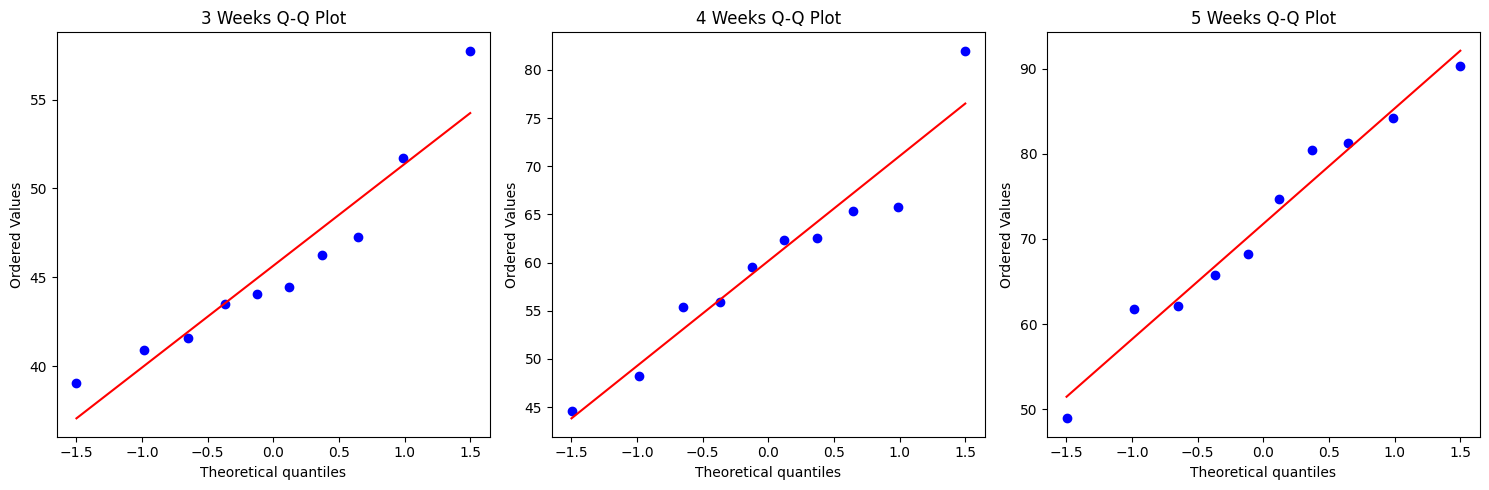

In [17]:
# Separate the IBU data into the three aging groups.
ibu_3weeks = ipa[ipa['Weeks'] == '3 Weeks']['IBU']
ibu_4weeks = ipa[ipa['Weeks'] == '4 Weeks']['IBU']
ibu_5weeks = ipa[ipa['Weeks'] == '5 Weeks']['IBU']

# Visual Method: Q-Q Plots
# A Q-Q plot compares the quantiles of our data against the quantiles of a theoretical normal distribution.
# If the data is normal, the points should fall along a straight diagonal line.
print("--- Visual Normality Check: Q-Q Plots ---")
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
stats.probplot(ibu_3weeks, dist="norm", plot=plt)
plt.title('3 Weeks Q-Q Plot')

plt.subplot(1, 3, 2)
stats.probplot(ibu_4weeks, dist="norm", plot=plt)
plt.title('4 Weeks Q-Q Plot')

plt.subplot(1, 3, 3)
stats.probplot(ibu_5weeks, dist="norm", plot=plt)
plt.title('5 Weeks Q-Q Plot')

plt.tight_layout()
plt.show()

In [18]:
print("\n--- Statistical Normality Check: Shapiro-Wilk Test ---")
shapiro_3weeks = stats.shapiro(ibu_3weeks)
print(f"Shapiro-Wilk Test for 3 Weeks: Statistic={shapiro_3weeks.statistic:.3f}, p-value={shapiro_3weeks.pvalue:.3f}")

shapiro_4weeks = stats.shapiro(ibu_4weeks)
print(f"Shapiro-Wilk Test for 4 Weeks: Statistic={shapiro_4weeks.statistic:.3f}, p-value={shapiro_4weeks.pvalue:.3f}")

shapiro_5weeks = stats.shapiro(ibu_5weeks)
print(f"Shapiro-Wilk Test for 5 Weeks: Statistic={shapiro_5weeks.statistic:.3f}, p-value={shapiro_5weeks.pvalue:.3f}")


--- Statistical Normality Check: Shapiro-Wilk Test ---
Shapiro-Wilk Test for 3 Weeks: Statistic=0.906, p-value=0.258
Shapiro-Wilk Test for 4 Weeks: Statistic=0.945, p-value=0.606
Shapiro-Wilk Test for 5 Weeks: Statistic=0.968, p-value=0.876


**Do the results of the normality test(s) support the assumption of normality?**

Visually: We see that the data points all fall very close to the fit line, this would indicate normally distributed data.

Shapiro-Wilk: Since the p-values are all high, we can reasonably assume the data is normal.


**Question 8**. Test the assumption of homogeneity of variance using both a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?


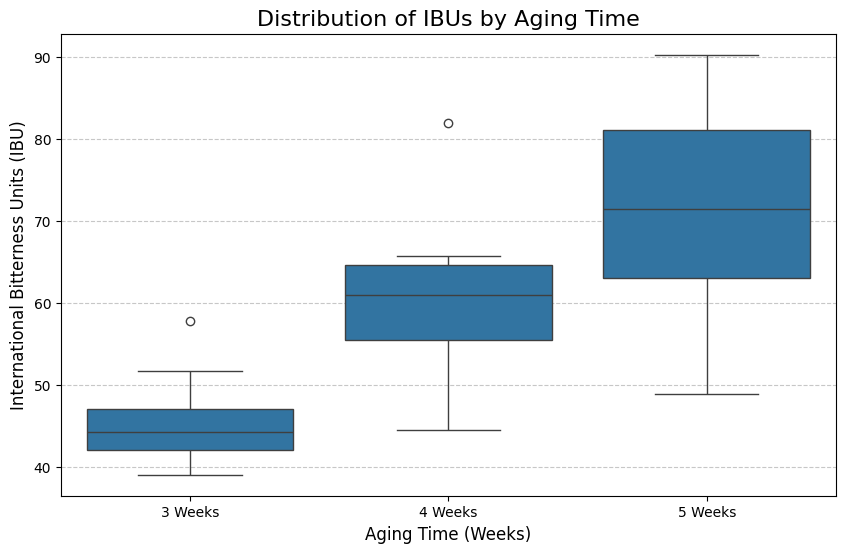

In [19]:
# Visual Method: Boxplot
# A boxplot is a good visual check. If the boxes are of roughly equal height,
# it suggests that the variances are similar across the groups.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Weeks', y='IBU', data=ipa)
plt.title('Distribution of IBUs by Aging Time', fontsize=16)
plt.xlabel('Aging Time (Weeks)', fontsize=12)
plt.ylabel('International Bitterness Units (IBU)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [20]:
# Statistical Method: Levene's Test
# Levene's test is a formal test for homogeneity of variance.
# The null hypothesis is that the variances are equal across all groups.
# We want the p-value to be greater than our significance level (e.g., 0.05) to support this assumption.
print("\n--- Statistical Homogeneity Check: Levene's Test ---")
levene_test = stats.levene(ibu_3weeks, ibu_4weeks, ibu_5weeks)
print(f"Levene's Test: Statistic={levene_test.statistic:.3f}, p-value={levene_test.pvalue:.3f}")


--- Statistical Homogeneity Check: Levene's Test ---
Levene's Test: Statistic=3.138, p-value=0.060


**Do the results of the test(s) support the assumption of homogeneity of variance?**

A p-value of 0.060 technically supports the assumption of homogeneity. The boxplots do slightly hint at a violation, but  since the statistical test concludes the assumpotion is met and the ANOVA test is robust, I feel confident in the ANOVA results.

**Question 9.** Report the F-statistic and its associated p-value from the one-way ANOVA model. Which of our two hypotheses is more strongly supported? Why?

The F-statistic and P-value (found above in previous questions) are F: 17.246546 and P-value: 0.000015 respectively. These results strongly support the alternative hypothesis. The p-value is so small compared to the standard significance level of 0.05. This would indicate that the IBUs across the 3 aging times are statistically significant and highly unlikely to have occurred by chance.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which aging times are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

In [21]:
# Import the necessary library for Tukey's HSD test.
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# Tukey's HSD post-hoc test.
tukey_test = pairwise_tukeyhsd(endog=ipa['IBU'],     # The outcome variable
                               groups=ipa['Weeks'], # The independent variable
                               alpha=0.05)         # The significance level

# Print the results of the test.
print(tukey_test)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
3 Weeks 4 Weeks   14.507 0.0083  3.4518 25.5622   True
3 Weeks 5 Weeks   26.134    0.0 15.0788 37.1892   True
4 Weeks 5 Weeks   11.627 0.0378  0.5718 22.6822   True
------------------------------------------------------


**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses.

Based on the statistical analysis, the aging time of the experimental IPA has a significant effect on its bitterness. The one-way ANOVA test provided a very low p-value (0.000015), which allowed us to confidently reject the null hypothesis.

The post-hoc Tukey's HSD test further clarified this finding by showing which specific aging times were different from one another. The results indicate that the bitterness level after 4 weeks and 5 weeks is significantly higher than after 3 weeks. However, there is no statistically significant difference in bitterness between the 4-week and 5-week aging periods. This suggests that the primary increase in bitterness occurs during the first few weeks of aging, and then levels off.

Overall, the analyses confirm the brewery's suspicion that aging time matters for this IPA's bitterness, with the most notable change happening between weeks 3 and 4.